In [ ]:
from gsm_benchmarker.results_analyser.bootstrap_result import BootstrapResult

from results_notebook_setup import RESULTS_ROOT, RESULTS_FOLDERS


In [2]:
RESULTS_FOLDERS.keys()

dict_keys(['gsm', 'nonformal', 'formal', 'short_code', 'long_code'])

In [3]:
boot_path = (RESULTS_ROOT / RESULTS_FOLDERS['gsm']).parent / 'bootstrap'

In [4]:
n_boot = 2000

bs1 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='1')
bs2 = BootstrapResult(boot_path, n_boot=n_boot, glmm_id='2')


## GLMM 1 - variant effect

In [5]:
bs1.boot_numbers  # bootstrap stats

,,requested,failed,nonconverged,singular,clean
model,variable,,,,,
Mathstral-7B-v0.1,is_variant,2000.0,0.0,1.0,0.0,1999.0
Meta-Llama-3-8B,is_variant,2000.0,0.0,0.0,0.0,2000.0
Meta-Llama-3-8B-Instruct,is_variant,2000.0,0.0,2.0,0.0,1998.0
Mistral-7B-Instruct-v0.1,is_variant,2000.0,0.0,2.0,0.0,1998.0
Mistral-7B-Instruct-v0.3,is_variant,2000.0,0.0,0.0,0.0,2000.0
Mistral-7B-v0.1,is_variant,2000.0,0.0,7.0,0.0,1993.0
Mistral-7B-v0.3,is_variant,2000.0,0.0,2.0,0.0,1998.0
Phi-3-medium-128k-instruct,is_variant,2000.0,0.0,40.0,0.0,1960.0
Phi-3-mini-128k-instruct,is_variant,2000.0,0.0,8.0,0.0,1992.0


In [6]:
# summary of clean estimates
bs1.boot_df

,,ci_upper_log,ci_lower_log,se_log,mean_log,median_log,p_value,n_requested,n_failed,n_nonconverged,n_singular,n_clean,elapsed_seconds,significant,ci_width_log
model,variable,,,,,,,,,,,,,,
Mathstral-7B-v0.1,is_variant,-0.037108,-1.636772,0.411317,-0.770811,-0.753924,0.042021,2000.0,0.0,1.0,0.0,1999.0,4686.362264,True,1.599664
Meta-Llama-3-8B,is_variant,-0.096309,-1.374645,0.319634,-0.708519,-0.705076,0.026000,2000.0,0.0,0.0,0.0,2000.0,4877.359903,True,1.278336
Meta-Llama-3-8B-Instruct,is_variant,0.065518,-1.541850,0.401929,-0.728287,-0.729621,0.078078,2000.0,0.0,2.0,0.0,1998.0,5022.078581,False,1.607367
Mistral-7B-Instruct-v0.1,is_variant,-0.089163,-1.278804,0.300793,-0.692053,-0.694678,0.025025,2000.0,0.0,2.0,0.0,1998.0,4423.448995,True,1.189641
Mistral-7B-Instruct-v0.3,is_variant,0.036228,-1.078176,0.283162,-0.506964,-0.506042,0.072000,2000.0,0.0,0.0,0.0,2000.0,4375.730866,False,1.114404
Mistral-7B-v0.1,is_variant,0.162101,-0.993912,0.303007,-0.405993,-0.407568,0.189664,2000.0,0.0,7.0,0.0,1993.0,4537.491882,False,1.156013
Mistral-7B-v0.3,is_variant,0.888871,-0.444801,0.334739,0.220823,0.219352,0.510511,2000.0,0.0,2.0,0.0,1998.0,4538.546032,False,1.333672
Phi-3-medium-128k-instruct,is_variant,0.444094,-2.014073,0.636637,-0.643214,-0.585985,0.304082,2000.0,0.0,40.0,0.0,1960.0,5770.344522,False,2.458167
Phi-3-mini-128k-instruct,is_variant,0.564985,-0.965581,0.385702,-0.162731,-0.167100,0.709839,2000.0,0.0,8.0,0.0,1992.0,5237.659014,False,1.530566


In [7]:
# check how many models agree w.r.t. significance of the result; show the ones that don't
bs1.disagreements_check()

Agreement: 18 / 20 models


,,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
model,variable,,,,,,
Meta-Llama-3-8B-Instruct,is_variant,-1.541850,0.065518,-1.363405,-0.081097,0.027253,False
gemma-2-2b,is_variant,-0.932146,0.340104,-0.314928,-0.313196,0.000000,True


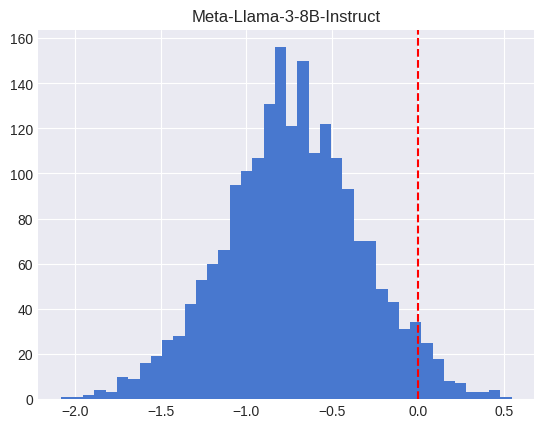

Meta-Llama-3-8B-Instruct / 'is_variant': skew=-0.02, % of resamples > 0: 3.9%


In [8]:
# plot the distribution of estimates in the bootstrap for models which do not agree with single GLMM significance verdict
bs1.plot_nonagreeing_estimates('is_variant')

For all models - also the agreeing ones

In [9]:
# quick scan for any other model where bootstrap mean diverges meaningfully from the original estimate
# (bias is <bootstrap mean estimate> minus <single GLMM estimate>
bs1.bias_check('is_variant')


,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
model,,,,,,
gemma-2-27b-it,-0.024847,-0.566730,-0.540122,-0.515275,-1.462651,0.432102
Phi-3-medium-128k-instruct,-0.020501,-0.643214,-0.585985,-0.565484,-1.510168,0.379200
gemma-2-9b,-0.013457,-0.859816,-0.847751,-0.834295,-1.487113,-0.181476
Mistral-7B-v0.3,0.012421,0.220823,0.219352,0.206930,-0.356921,0.770781
Phi-3-mini-128k-instruct,-0.012353,-0.162731,-0.167100,-0.154748,-0.843341,0.533846
Mathstral-7B-v0.1,-0.012248,-0.770811,-0.753924,-0.741676,-1.415893,-0.067458
gemma-2b,0.012046,-0.859917,-0.878788,-0.890834,-1.559542,-0.222126
gemma-2-2b-it,0.011043,-0.006003,-0.005182,-0.016225,-0.599179,0.566729
gemma-7b-it,0.011025,-0.700725,-0.696560,-0.707585,-1.259303,-0.155866


In [10]:
# CI width ratio (bootstrap CI width / original CI width) across all models, excluding the ones which did not converge for single GLMM
bs1.ci_width_check('is_variant')

,width_ratio_log
count,19.000000
mean,1.166424
std,0.099340
min,1.025502
25%,1.081894
50%,1.182646
75%,1.247594
max,1.335327


In [11]:
# bootstrap estimate distribution skew check across all models
bs1.skew_check('is_variant')

Models with absolute skew > 0.5:
	 Phi-3-medium-128k-instruct -0.6257861014944508
	 gemma-2-9b-it -0.6989905931465913
	 gemma-2b-it 0.676823344870594


## GLMM2

In [12]:
bs2.boot_numbers.xs('is_variant', level=1)  # shared for both variables


,requested,failed,nonconverged,singular,clean
model,,,,,
Mathstral-7B-v0.1,2000.0,0.0,12.0,0.0,1988.0
Meta-Llama-3-8B,2000.0,0.0,0.0,0.0,2000.0
Meta-Llama-3-8B-Instruct,2000.0,0.0,32.0,0.0,1968.0
Mistral-7B-Instruct-v0.1,2000.0,0.0,21.0,0.0,1979.0
Mistral-7B-Instruct-v0.3,2000.0,0.0,0.0,0.0,2000.0
Mistral-7B-v0.1,2000.0,0.0,9.0,0.0,1991.0
Mistral-7B-v0.3,2000.0,0.0,2.0,0.0,1998.0
Phi-3-medium-128k-instruct,2000.0,0.0,26.0,0.0,1974.0
Phi-3-mini-128k-instruct,2000.0,0.0,115.0,0.0,1885.0


### a) number effect

In [13]:
bs2.disagreements_check('gamma_c')

Agreement: 19 / 20 models


,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
model,,,,,,
gemma-2b,-0.340147,0.009484,-0.329908,-0.007305,0.040489,False


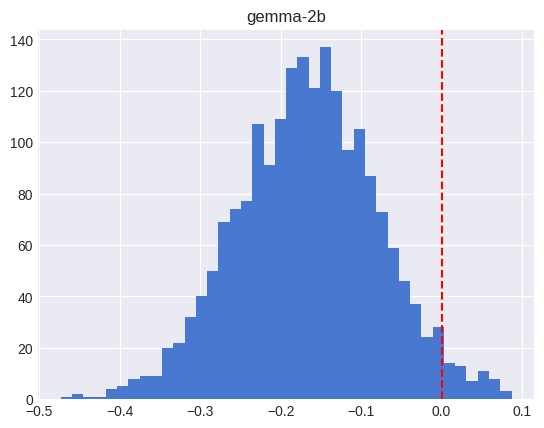

gemma-2b / 'gamma_c': skew=-0.05, % of resamples > 0: 3.2%


In [14]:
bs2.plot_nonagreeing_estimates('gamma_c')

In [15]:
bs2.bias_check('gamma_c')

,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
model,,,,,,
gemma-2-2b,-0.013481,-0.217314,-0.215407,-0.201926,-0.202824,-0.201027
Phi-3-medium-128k-instruct,0.009530,-0.265913,-0.260900,-0.270430,-0.442549,-0.098312
gemma-2-9b-it,0.007955,-0.301647,-0.298235,-0.306190,-0.473158,-0.139223
gemma-2-27b-it,-0.007378,0.105535,0.101788,0.109166,-0.117157,0.335488
Meta-Llama-3-8B,-0.006270,0.090025,0.090485,0.096754,-0.051862,0.245371
gemma-2-2b-it,-0.005984,-0.081432,-0.082845,-0.076861,-0.220022,0.066300
Mistral-7B-Instruct-v0.3,-0.004178,-0.074122,-0.074885,-0.070707,-0.195514,0.054099
gemma-7b-it,0.004039,-0.129862,-0.125751,-0.129789,-0.254969,-0.004610
gemma-2b,0.003313,-0.166105,-0.165293,-0.168607,-0.329908,-0.007305


In [16]:
bs2.ci_width_check('gamma_c')

,width_ratio_log
count,19.000000
mean,1.306213
std,0.187056
min,0.967963
25%,1.148280
50%,1.264791
75%,1.470614
max,1.570660


In [17]:
bs2.skew_check('gamma_c')

No models with absolute skew > 0.5


### b) number-effect-corrected variant effect

In [18]:
bs2.disagreements_check('is_variant')

Agreement: 17 / 20 models


,boot_ci_lower_log,boot_ci_upper_log,wald_ci_lower_log,wald_ci_upper_log,wald_p_value,wald_nonconvergent
model,,,,,,
Mathstral-7B-v0.1,-1.542536,-0.006562,-1.417425,0.002692,0.050875,False
gemma-2-2b,-0.796586,0.731844,-0.097989,-0.096192,0.000000,True
gemma-2b,-1.393076,0.114530,-1.414340,-0.039749,0.038143,False


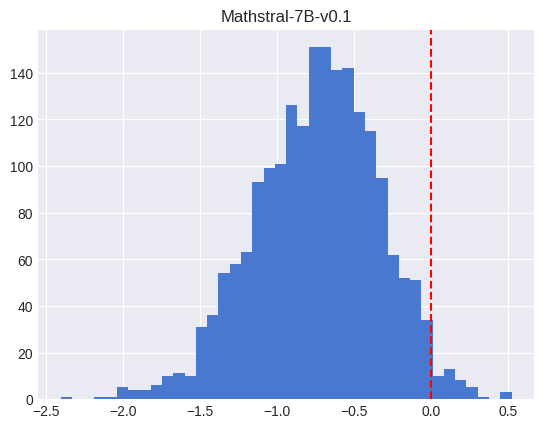

Mathstral-7B-v0.1 / 'is_variant': skew=-0.25, % of resamples > 0: 2.3%


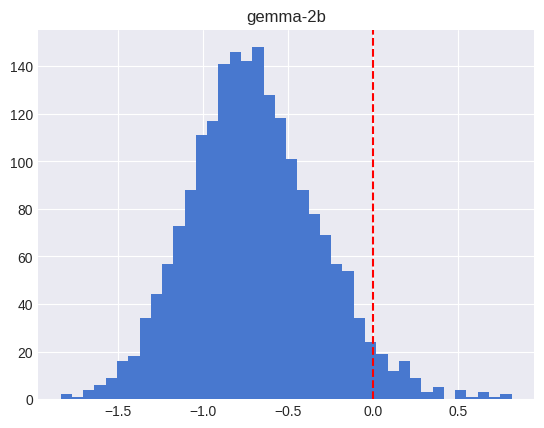

gemma-2b / 'is_variant': skew=0.34, % of resamples > 0: 4.0%


In [19]:
bs2.plot_nonagreeing_estimates('is_variant')

In [20]:
bs2.bias_check('is_variant')


,bias_log,boot_mean_log,boot_median_log,wald_estimate,wald_ci_lower_log,wald_ci_upper_log
model,,,,,,
gemma-2-2b,0.026132,-0.059548,-0.070959,-0.097090,-0.097989,-0.096192
gemma-7b-it,0.015839,-0.549595,-0.537178,-0.553017,-1.128229,0.022196
gemma-2-2b-it,0.012924,0.087241,0.084690,0.071765,-0.534586,0.678116
Mistral-7B-v0.3,0.011172,0.207556,0.204701,0.193529,-0.388808,0.775866
phi-2,0.010483,-1.178872,-1.164196,-1.174679,-1.735486,-0.613873
Mathstral-7B-v0.1,-0.010126,-0.737843,-0.717493,-0.707366,-1.417425,0.002692
Mistral-7B-Instruct-v0.1,-0.008366,-0.410542,-0.414755,-0.406389,-0.961617,0.148839
Phi-3-medium-128k-instruct,-0.008356,-0.310612,-0.259128,-0.250772,-1.217124,0.715579
gemma-2b,0.008160,-0.696048,-0.718884,-0.727044,-1.414340,-0.039749


In [21]:

bs2.ci_width_check('is_variant')

,width_ratio_log
count,19.000000
mean,1.105527
std,0.086604
min,0.969825
25%,1.040456
50%,1.100792
75%,1.153699
max,1.284114


In [22]:
bs2.skew_check('is_variant')

Models with absolute skew > 0.5:
	 Phi-3-medium-128k-instruct -0.6058290766223051
	 gemma-2-9b-it -0.7362240836953623
	 gemma-2b-it 0.7401649196884466
